In [2]:
%pip install pandas matplotlib plotly seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import seaborn as sns

# Importazione dei dati


In [4]:
path="clean_datasets"

In [5]:
# Load datasets
try:
    df_actors = pd.read_csv(os.path.join(path, "df_actors.csv"))
    df_countries = pd.read_csv(os.path.join(path, "df_countries.csv"))
    df_crew = pd.read_csv(os.path.join(path, "df_crew.csv"))
    df_released_movies = pd.read_csv(os.path.join(path, "df_released_movies.csv"))
    df_unreleased_movies = pd.read_csv(os.path.join(path, "df_unreleased_movies.csv"))
    df_movies = pd.read_csv(os.path.join(path, "df_movies.csv"))
    df_languages = pd.read_csv(os.path.join(path, "df_languages.csv"))
    df_posters = pd.read_csv(os.path.join(path, "df_posters.csv"))
    df_releases = pd.read_csv(os.path.join(path, "df_releases.csv"))
    df_themes = pd.read_csv(os.path.join(path, "df_themes.csv"))
    df_genres = pd.read_csv(os.path.join(path, "df_genres.csv"))
    df_studios = pd.read_csv(os.path.join(path, "df_studios.csv"))
    df_tomatoes= pd.read_csv(os.path.join(path, "df_tomatoes.csv"))
    df_oscars = pd.read_csv(os.path.join(path, "df_oscars.csv"))
except Exception as e:
    print(e)

# **Analisi dei Dati**


## Trend di popolarità (rating) dei film nel tempo

- Come è cambiato il rating del pubblico dei film nel tempo?
- Come è cambiato il rating della critica dei film nel tempo?
- Quali sono state le cause di questo cambiamento?
- Il rating dei film è influenzato anche da altri fattori? Proviamo a trovare correlazioni con il genere e con la durata


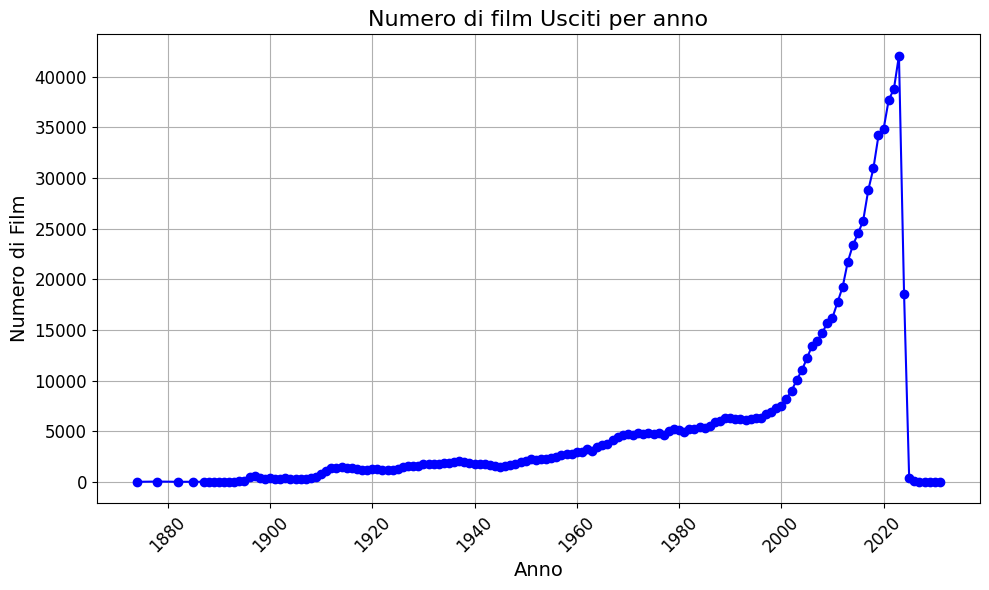

In [6]:
films_per_year = df_released_movies.groupby("date").size()
plt.figure(figsize=(10, 6))
plt.plot(films_per_year.index, films_per_year.values, marker='o', linestyle='-', color='blue', label="Numero di Film")

plt.title("Numero di film Usciti per anno", fontsize=16)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Numero di Film", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
max_y = films_per_year.max()
yticks = list(range(0, max_y + 10, 5000))  
plt.yticks(yticks, fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

Vi è stato un chiaro incremento nel tempo nel numero di film prodotti per anno, fino ad un improvviso crollo, che possiamo attribuire probabilmente alla nascita e all'evoluzione del Covid degli anni recenti.

Ora possiamo analizzare come invece si è evoluta in media la valutazione de film nei diversi anni da parte della critica.


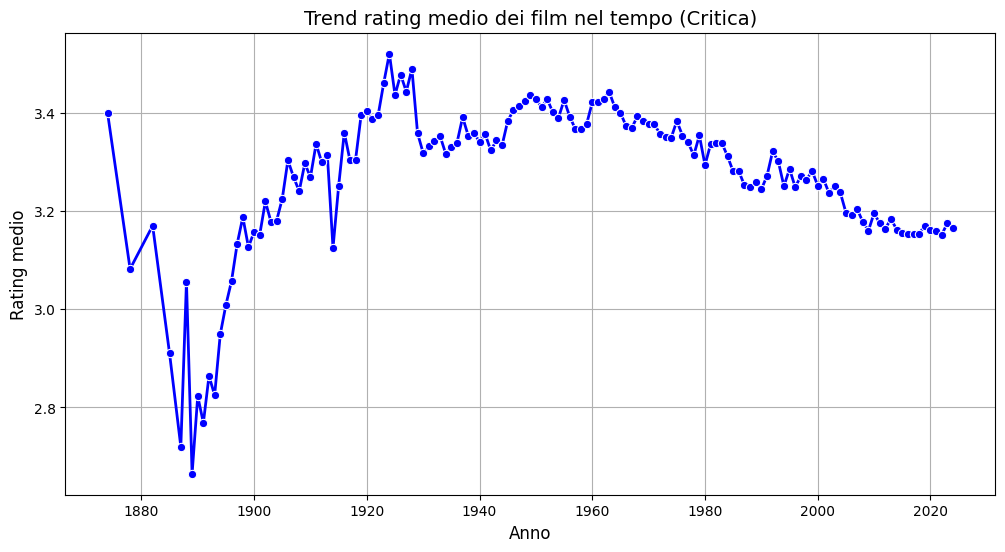

In [7]:
rating_trend = df_released_movies.groupby('date')['rating'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=rating_trend, x='date', y='rating', marker='o', linewidth=2, color='b')
plt.title("Trend rating medio dei film nel tempo (Critica)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True)
plt.show()

Negli inizi degli anni tra il 1920 e il 1940 abbiamo un picco di rating medio, mentre da quel punto possiamo notare un lento calo nelle valutazioni effettuate dal pubblico.


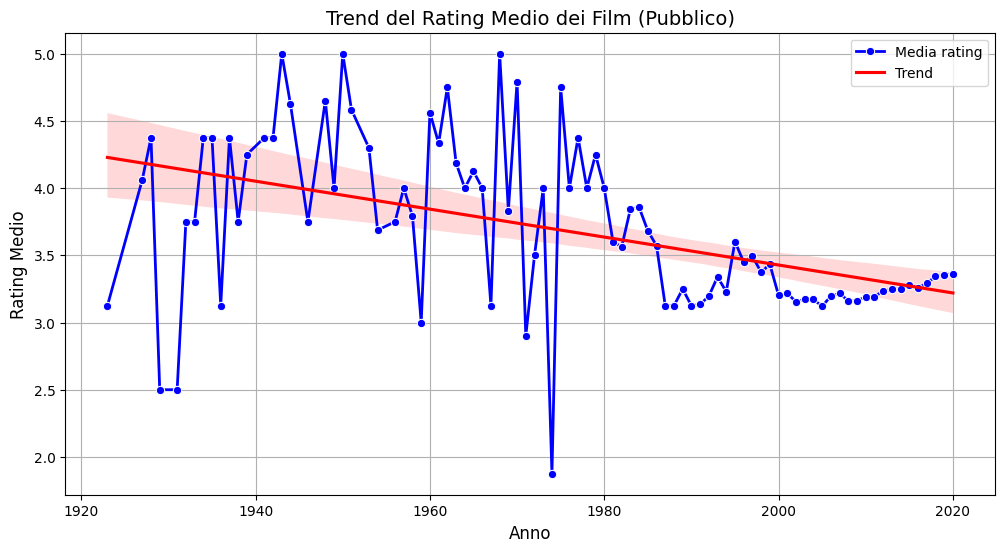

In [8]:
rating_trend = df_tomatoes.copy()

# Convert review_date to datetime
rating_trend['year'] = pd.to_datetime(rating_trend['review_date'], errors='coerce').dt.year

rating_trend = rating_trend[(rating_trend['year'] >= 1830) & (rating_trend['year'] <= 2025)]
rating_trend = rating_trend.groupby('year')['rating'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=rating_trend['year'], y=rating_trend['rating'], marker="o",linewidth=2, color='b', label="Media rating")
sns.regplot(x=rating_trend['year'], y=rating_trend['rating'], scatter=False, color="red", label="Trend")
plt.title("Trend del Rating Medio dei Film (Pubblico)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating Medio", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Possiamo notare come anche i rating dei critici siano stato in calo durante il tempo, fino ad una quasi stabilizzazione negli anni più recenti, questo però nota come i valori da parte dei critici siano diversi rispetto a quello del pubblico.
Quindi anche se in comune vi è il tranding verso il basso, i critici annualmente,in media, anche assegnato generalmente valori più alti come rating verso i film in uscita.
Perciò possiamo intuire che sia il pubblico che ha sviluppato un particolare per cui la popolarità dei film sia diminuita nel tempo.


Ci concentreremo principalmente sull'analisi dei rating del pubblico, per analizzare una valutazione più ampia.
Utiliziamo diversi boxplot per esplicitare la distribuzione del rating nel tempo.


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/245705080.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  public_avg = rating_public.groupby('year_bin')['rating'].mean().reset_index()
/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/245705080.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  critics_avg = rating_critics.groupby('year_bin')['critics_rating'].mean().reset_index()


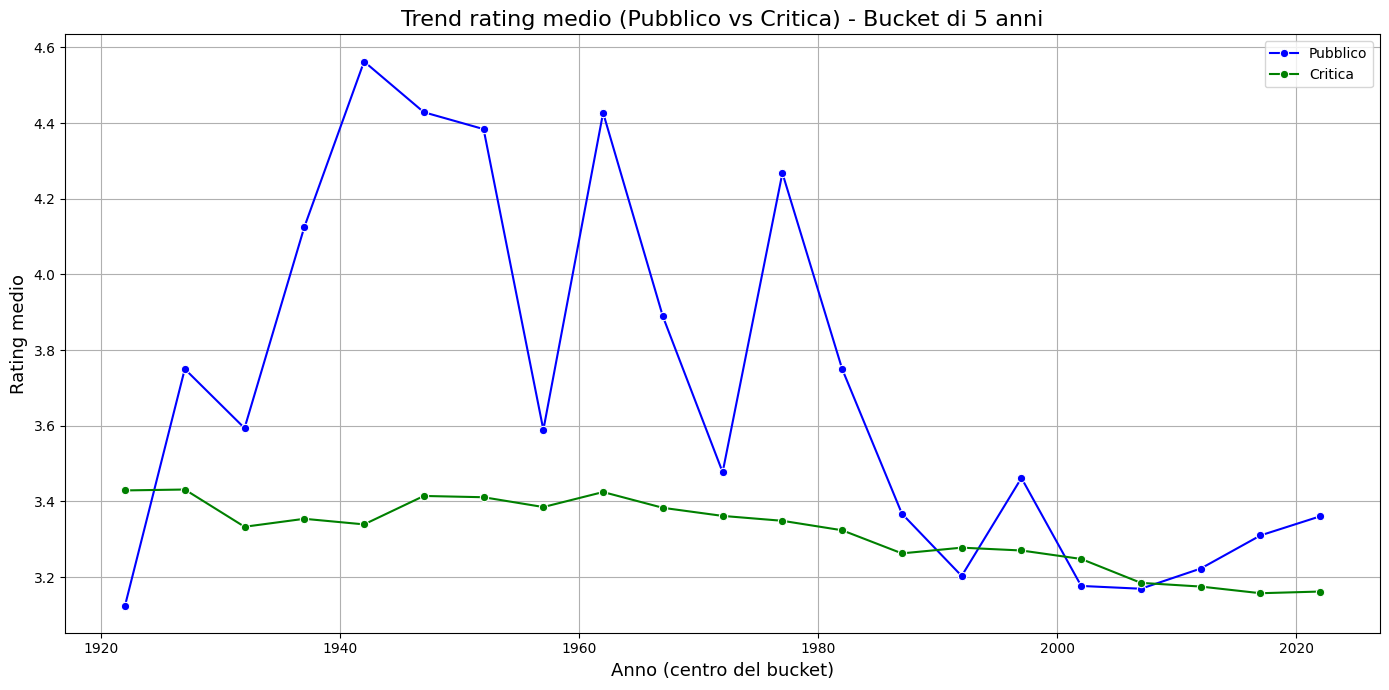

In [9]:
# --- Prepara dati rating pubblico
rating_public = df_tomatoes.copy()
rating_public['year'] = pd.to_datetime(rating_public['review_date'], errors='coerce').dt.year
rating_public = rating_public[(rating_public['year'] >= 1920) & (rating_public['year'] <= 2025)]

# --- Prepara dati rating critica
rating_critics = df_released_movies.copy()
rating_critics = rating_critics.rename(columns={'rating': 'critics_rating', 'date': 'year'})

# --- Creare bins di 5 anni
bins = list(range(1920, 2030, 5))  # fino al 2025
rating_public['year_bin'] = pd.cut(rating_public['year'], bins=bins, right=False)
rating_critics['year_bin'] = pd.cut(rating_critics['year'], bins=bins, right=False)

# --- Calcolare media per ogni bin
public_avg = rating_public.groupby('year_bin')['rating'].mean().reset_index()
public_avg.rename(columns={'rating': 'public_rating'}, inplace=True)

critics_avg = rating_critics.groupby('year_bin')['critics_rating'].mean().reset_index()

# --- Unire i due dataframe
merged_rating = pd.merge(public_avg, critics_avg, on='year_bin', how='inner')

# --- Pulizia: usare il centro dei bin per plottare
merged_rating['year_mid'] = merged_rating['year_bin'].apply(lambda x: x.left + 2)

# --- Plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='year_mid', y='public_rating', data=merged_rating, marker='o', color='blue', label='Pubblico')
sns.lineplot(x='year_mid', y='critics_rating', data=merged_rating, marker='o', color='green', label='Critica')

plt.title("Trend rating medio (Pubblico vs Critica) - Bucket di 5 anni", fontsize=16)
plt.xlabel("Anno (centro del bucket)", fontsize=13)
plt.ylabel("Rating medio", fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Se il rating medio della critica dal 1920 fino ad oggi è pressochè stabile con un lieve calo dal 1960 in poi, possiamo notare come invece il rating del pubblico varia spesso di anno in anno, probabilmente perchè i gusti cambiano e


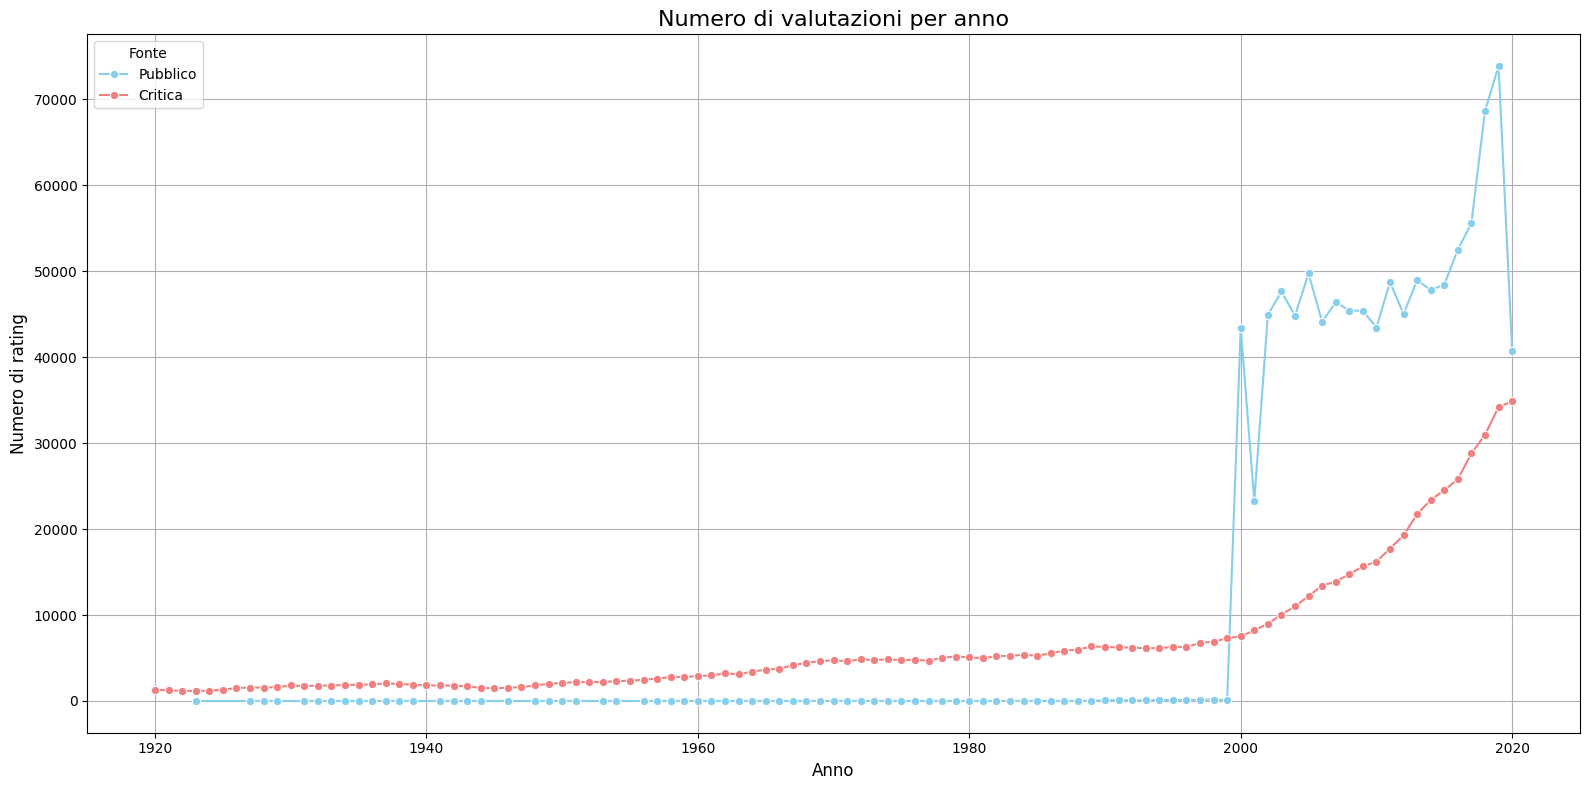

In [10]:
# --- Pubblico
public = df_tomatoes.copy()
public['year'] = pd.to_datetime(public['review_date'], errors='coerce').dt.year
public = public.dropna(subset=['year'])
public['year'] = public['year'].astype(int)
public = public[(public['year'] >= 1920) & (public['year'] <= 2020)]
public_counts = public.groupby('year').size().reset_index(name='count')
public_counts['source'] = 'Pubblico'

# --- Critica
critics = df_released_movies.copy()
critics = critics.dropna(subset=['date'])
critics['year'] = critics['date'].astype(int)
critics = critics[(critics['year'] >= 1920) & (critics['year'] <= 2020)]
critics_counts = critics.groupby('year').size().reset_index(name='count')
critics_counts['source'] = 'Critica'

# --- Unione
df_counts = pd.concat([public_counts, critics_counts], ignore_index=True)

# --- Plot
plt.figure(figsize=(16, 8))
sns.lineplot(data=df_counts, x='year', y='count', hue='source', marker='o', palette={'Pubblico': 'skyblue', 'Critica': 'lightcoral'})

plt.title("Numero di valutazioni per anno", fontsize=16)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Numero di rating", fontsize=12)
plt.legend(title="Fonte")
plt.grid(True)
plt.tight_layout()
plt.show()

Abbiamo dedotto quindi che nel nostro dataset non sono presenti un significativo numero di valutazioni del pubblico prima del 2000. La parte interessante quindi è dal 2000 in poi, e come possiamo vedere dal grafico precedente le linee del rating medio tra critica e pubblico si stabilizza pressochè sullo stesso valore.

Possiamo dedurre che i gusti del pubblico e dei critici si allineano, negli ultimi anni.


## Proviamo a scoprire, nonostante le poche valutazioni per il giudizio del pubblico, alcuni fattori di correlazione tra il rating e il genere

Esiste un genere che sbilancia in positivo o in negativo il rating medio per periodo?


In [11]:
# 1. Merge dei tuoi dati
movies_genres = pd.merge(df_released_movies, df_genres, left_on="id", right_on="id_film", how="inner")
movies_genres = movies_genres.sort_values(by=['id', 'genre']).drop_duplicates(subset=['id'], keep='first')

rating_medio = df_tomatoes.groupby('movie_title')['rating'].mean().reset_index()
altri_dati = df_tomatoes.drop(columns=['rating']).drop_duplicates(subset=['movie_title'], keep='first')
df_unificato = pd.merge(altri_dati, rating_medio, on='movie_title', how='inner')

# 2. Merge critico + pubblico
moviessss = pd.merge(movies_genres, df_unificato, left_on="name", right_on="movie_title", how="inner")

# 3. Filtra i top generi
top_genres = moviessss["genre"].value_counts().nlargest(10).index
filtered_movies = moviessss[moviessss["genre"].isin(top_genres)]

# 4. Prepara i dati per plottare
df_meltato = filtered_movies.melt(
    id_vars=['genre'],
    value_vars=['rating_x', 'rating_y'],  # rating_x = critica, rating_y = pubblico
    var_name='Rating_Type',
    value_name='Rating'
)


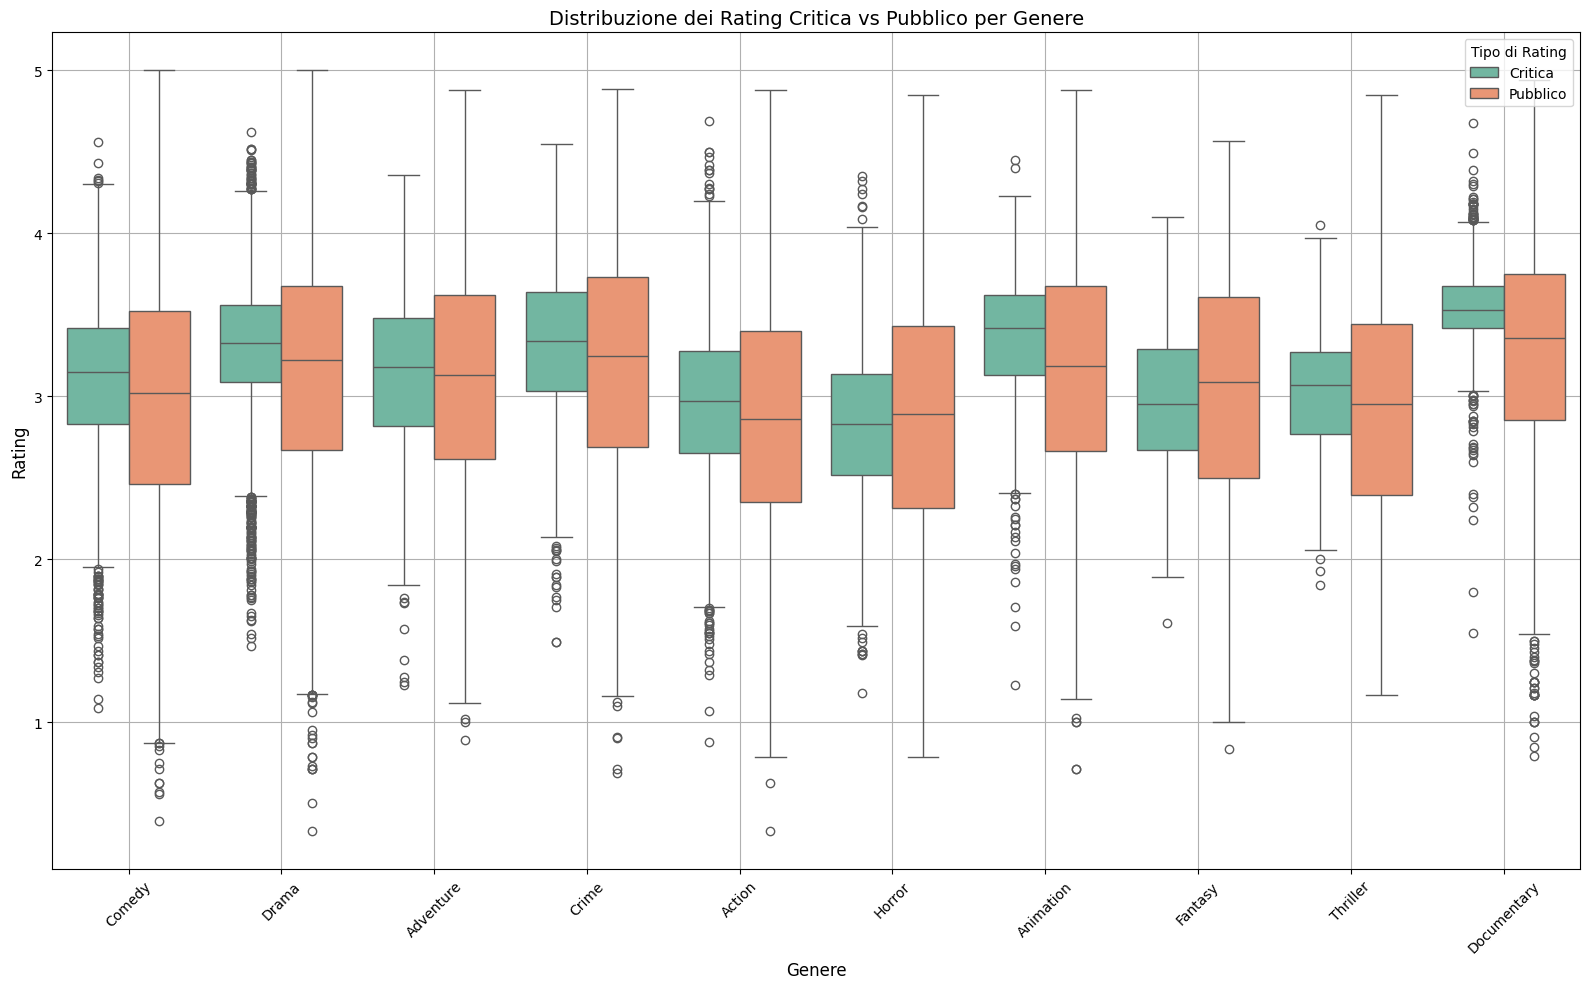

In [12]:
# --- Palette personalizzata
custom_palette = {
    'rating_x': '#66c2a5',  # verde acqua (Critica)
    'rating_y': '#fc8d62',  # arancione (Pubblico)
}

plt.figure(figsize=(16, 10))

# --- Disegna il boxplot
ax = sns.boxplot(
    data=df_meltato,
    x="genre",
    y="Rating",
    hue="Rating_Type",
    palette=custom_palette
)

# --- Crea handle e label manualmente
handles, labels = ax.get_legend_handles_labels()

plt.title("Distribuzione dei Rating Critica vs Pubblico per Genere", fontsize=14)
plt.xlabel("Genere", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

# --- Ricrea la legenda con i colori corretti
plt.legend(
    handles=handles,
    labels=["Critica", "Pubblico"],  # Rispetta l'ordine dei tuoi dati
    title="Tipo di Rating",
    loc='upper right'
)

plt.tight_layout()
plt.show()

Vediamo come chiaramente i documentari sono il genere che ha mantenuto una media delle valutazioni più alta durante gli anni, assieme alla musica.
Tutti i generi nella prima fascia temporale hanno una mediana simile (3.0 - 3.5) quindi possiamo dedurre che i cambiamenti sono avvenuti solo successivamente.
La musica è l'unico genere che ha avuto una continua crescita, mentre gli altri generi dopo una crescita iniziale hanno avuto un calo finale rispetto al loro inizio.
In ogni genere notiamo però come la presenza di outsider negativi sia aumentata nel tempo.
Capiamo quindi che vi è una correlazione tra il genere di un film e il suo rating.


Tornando al primo grafico sul numero di film pubblicati nel tempo,potremmo pensare che la causa di questo calo di valutazioni sia data dal continuo aumento nel numero di film che vengono prodotti.
Un numero ingente di film ogni anno porterebbe ad una possibile ripetitività nei film che di conseguenza annoierebbe lo spettatore medio.


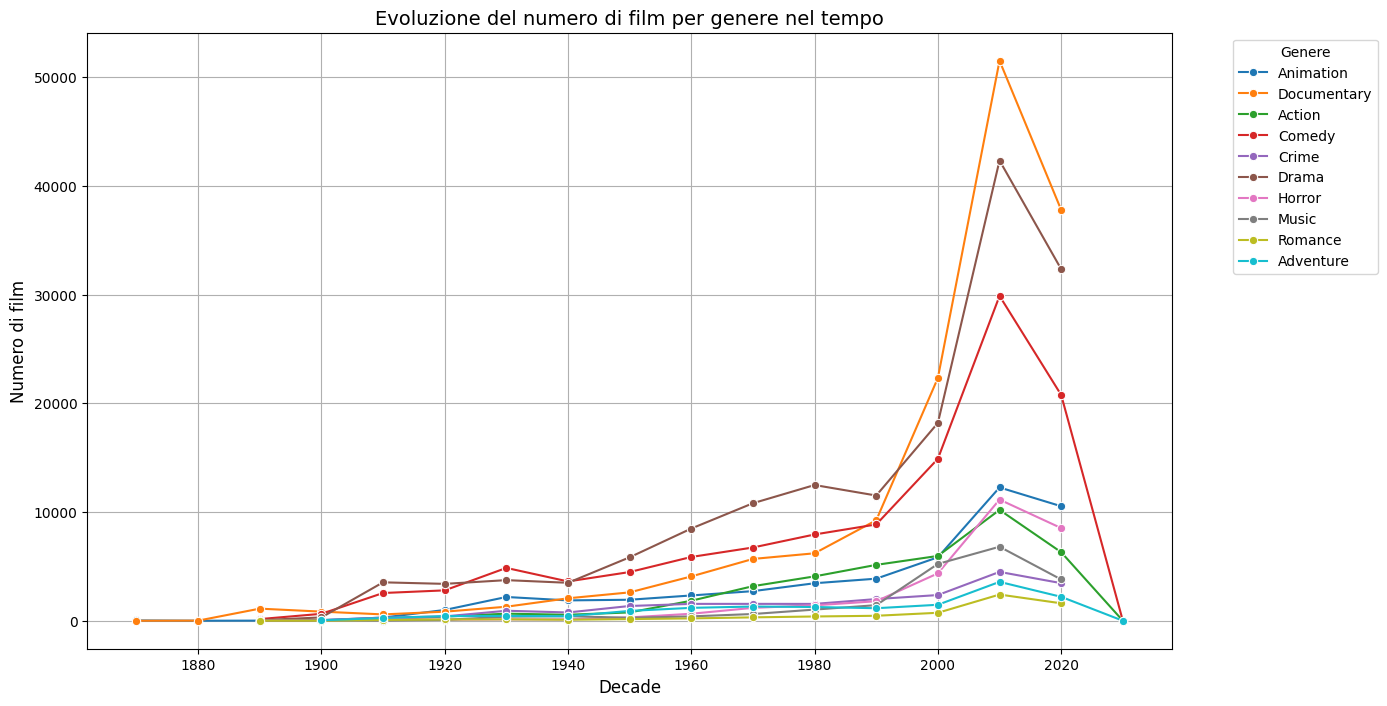

In [13]:
movies_genres['decade'] = (movies_genres['date'] // 10) * 10
genre_trend = movies_genres.groupby(['decade', 'genre']).size().reset_index(name='film_count')
#scegliamo i 10 generi più popolari
top_genres = movies_genres["genre"].value_counts().nlargest(10).index
filtered_trend = genre_trend[genre_trend['genre'].isin(top_genres)]

# Creare il grafico a linee
plt.figure(figsize=(14, 8))
sns.lineplot(data=filtered_trend, x="decade", y="film_count", hue="genre", marker="o")
plt.title("Evoluzione del numero di film per genere nel tempo", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Numero di film", fontsize=12)
plt.legend(title="Genere", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

Vi è una crescita sostanziale tra il numero di film pubblicati, possiamo verificare se vi è una dipendenza con il rating per chiederci se producendo un numero maggiore di film la loro qualità diminuisca.


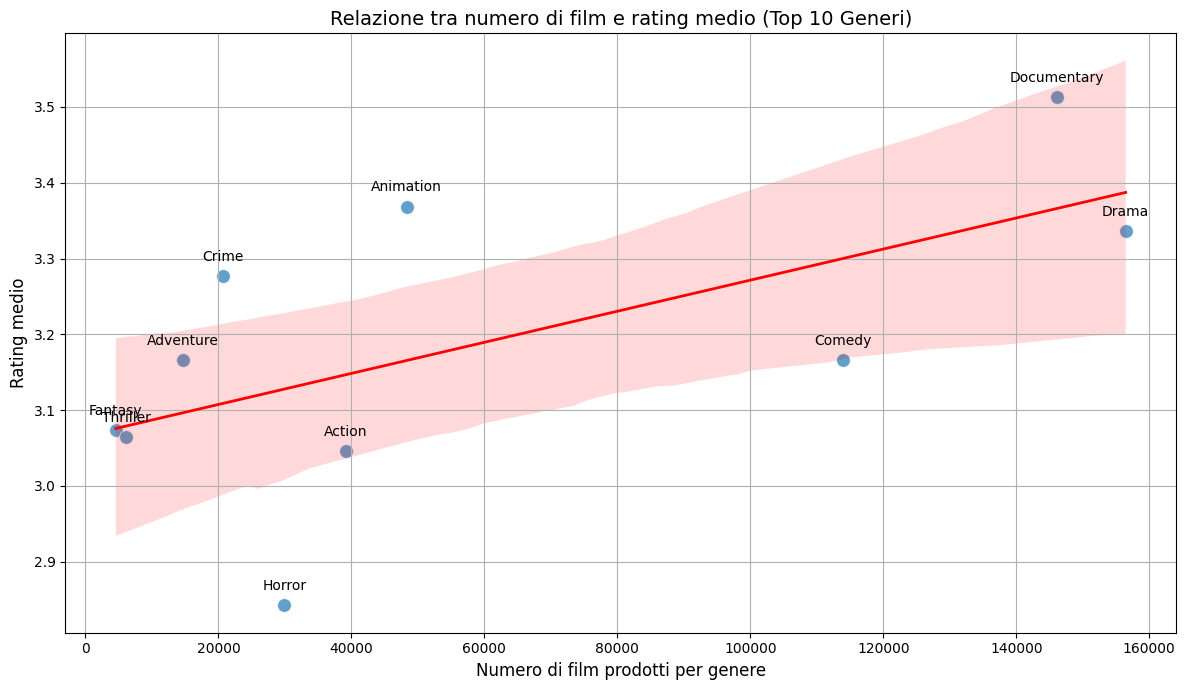

In [14]:
# --- Filtro i top 10 generi
top_genres = moviessss["genre"].value_counts().nlargest(10).index

# --- Calcolo le statistiche solo sui top generi
genre_stats_top = movies_genres[movies_genres["genre"].isin(top_genres)].groupby("genre").agg(
    film_count=("id_film", "count"),
    avg_rating=("rating", "mean")
).reset_index()

# --- Plotta
plt.figure(figsize=(12, 7))

sns.scatterplot(data=genre_stats_top, x="film_count", y="avg_rating", alpha=0.7, s=100)

# Linea di tendenza
sns.regplot(data=genre_stats_top, x="film_count", y="avg_rating", scatter=False, color="red", line_kws={"linewidth": 2})

# Titoli ed etichette
plt.title("Relazione tra numero di film e rating medio (Top 10 Generi)", fontsize=14)
plt.xlabel("Numero di film prodotti per genere", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True)

# Etichette sui punti
for i, row in genre_stats_top.iterrows():
    plt.text(row["film_count"], row["avg_rating"] + 0.02, row["genre"], fontsize=10, ha='center')

plt.tight_layout()
plt.show()


Per rispondere alla nostra domanda precedente, notiamo che in realtà la correlazione è leggermente positiva (linea rossa in crescita), quindi anche se il numero di film di genere aumenta, la maggior parte dei rating medi tende a salire.
Per esempio il Drama è il genere più prolifico, perchè con un vasto numero di film prodotti mantiene un rating medio del 3.3 .
Notiamo che i Documentari hanno il rating medio più alto mentre gli Horror quello minore.
Quindi non vediamo un chiaro calo del rating, generi molto prodotti riescono a mantenere abbastanza un buon rating medio, mentre quelli meno prodotti hanno rating più alti ma con molta variabilità.


Resta però che anche se in piccola quantità, la quantità di film prodotti per genere impatta il voto medio, probabilmente a causa di una minore attenzione alla qualità dei film stessi.


Possiamo pensare però che sia la durata dei film stessi a incidere sul loro rating, quindi film più lunghi possono avere valutazioni peggiori o migliori.


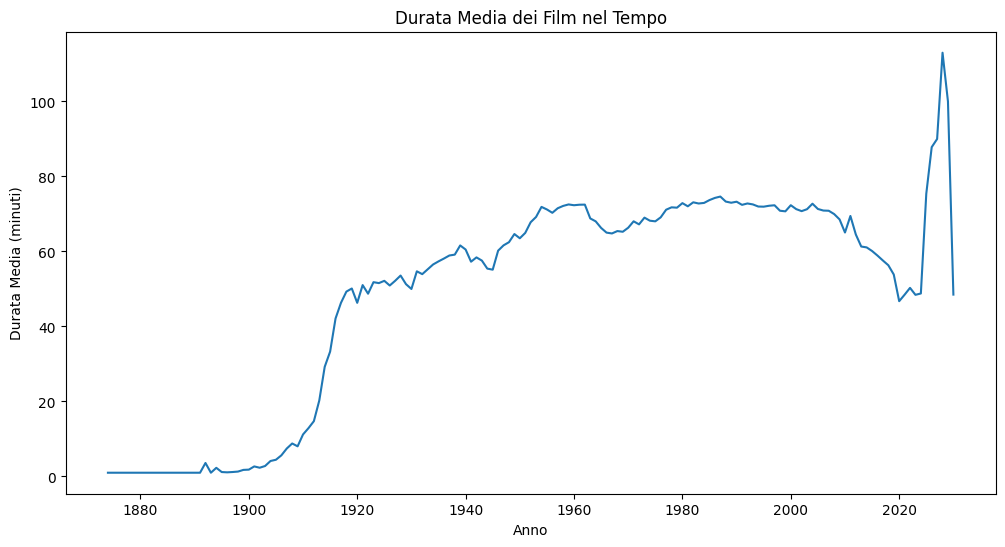

In [15]:
durata_media_anni = df_released_movies.groupby('date')['minute'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=durata_media_anni['date'], y=durata_media_anni['minute'])
plt.title("Durata Media dei Film nel Tempo")
plt.xlabel("Anno")
plt.ylabel("Durata Media (minuti)")
plt.show()


La durata dei film in media dell'anno è aumentata, questo ci può far pensare che questo aumento sia la causa della diminuzione delle valutazioni.

Creiamo uno scatterplot per rappresentare la correlazione tra durata e rating.


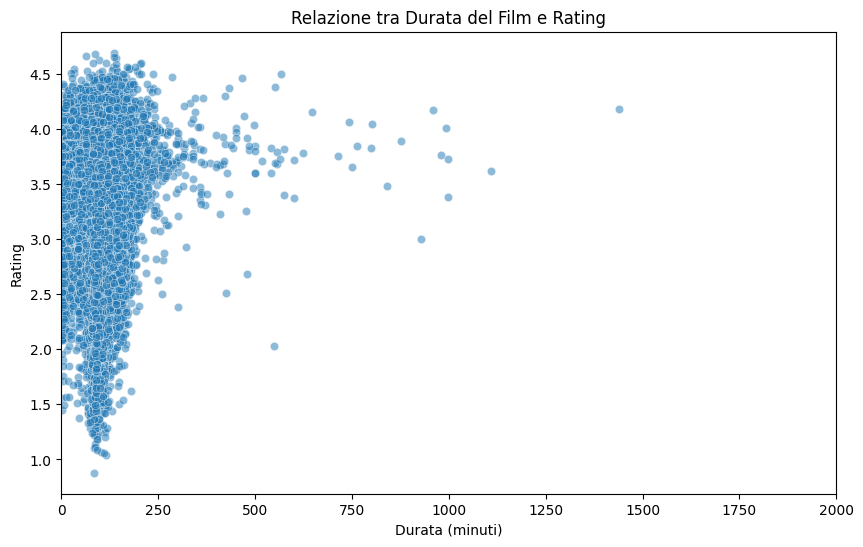

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_released_movies['minute'], y=df_released_movies['rating'], alpha=0.5)
plt.xlim(0, 2000)
plt.title("Relazione tra Durata del Film e Rating")
plt.xlabel("Durata (minuti)")
plt.ylabel("Rating")
plt.show()

Vediamo che la correlazione non è presente, essendo il valore piu vicino 0 rispetto ad 1 o -1.
Quindi possiamo affermare che anche la durata dei film non sia una delle cause principali della diminuzione del rating.


### Risultato analisi:

Uno dei fattori più evidenti che abbiamo analizzato è che il numero di film prodotti è aumentato notevolmente nel tempo. Questo porta a diversi effetti:

Diminuzione della qualità media: Con l'aumento del numero di film, è più probabile che vengano prodotti molti film di qualità inferiore, riducendo il rating medio complessivo.
Sovraccarico del pubblico: Con troppi film disponibili, gli spettatori possono diventare più esigenti e difficilmente daranno buone valutazioni.
Produzione industrializzata: La crescente commercializzazione e standardizzazione di molti film può portare a sceneggiature meno originali,con storie ripetute molte volte,abbassando la percezione della qualità.

Sicuramente il cambiamento del gusto del pubblico,infatti possiamo notare che ci sono generi che hanno un valore molto maggiore in alcune fasce annuali, come il Drama negli anni del dopoguerra e i generi Music negli anni più recenti.
Infine quasi sicuramente l'accessibilità alle recensioni è aumentata, causando quindi il voto del pubblico di essere maggiore con il tempo con l'avvento delle critiche online.


---


## Analisi degli Oscar dei paesi produttori di film

- Vi sono paesi che hanno prodotto più film di alto successo ? Se si, di conseguenza quei paesi avranno vinto più Oscar con film prodotti dal loro?
- Gli studios di Hollywood e la cinematografia francese, rispecchiano le aspettative e la nomea che si portano dietro in vincite di Oscars?
- È presente un genere di film che si discosta particolarmente rispetto agli altri per il numero di Oscar vinti?


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/3868369383.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


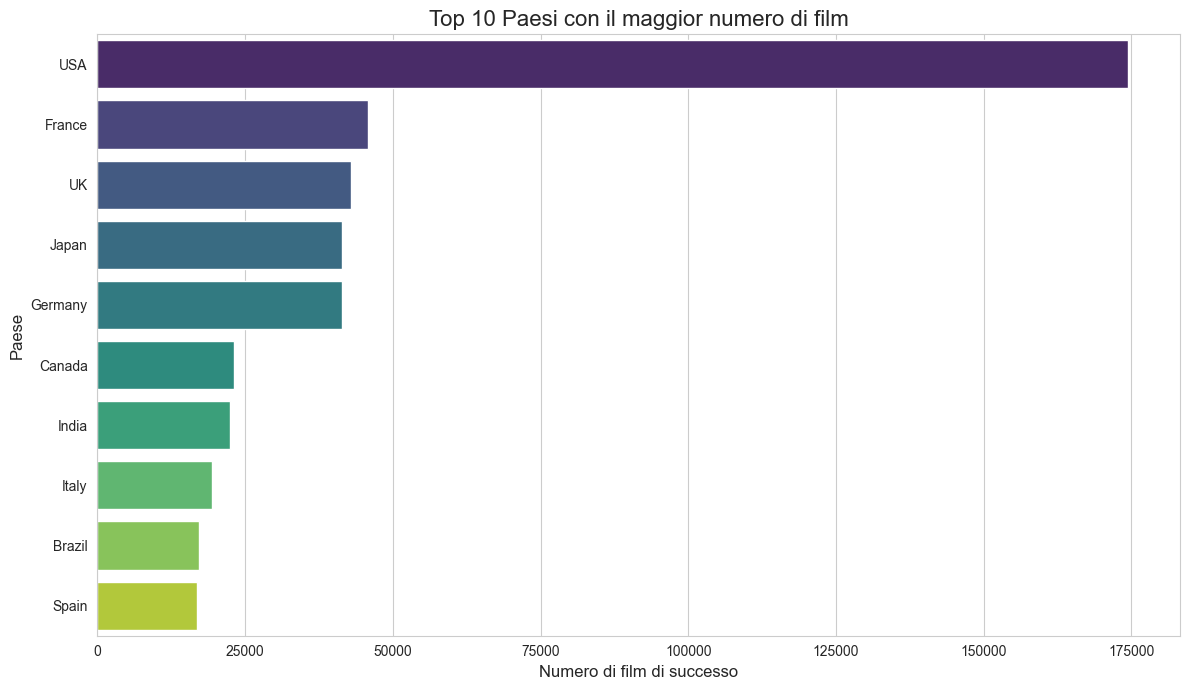

In [17]:
successful_movies_countries= df_movies.merge(df_countries,left_on="id",right_on="id_film", how="left")
successful_movies_per_country = (
    successful_movies_countries.groupby('country')['id'].count().reset_index().rename(columns={'id': 'successful_movies_count'})
)
successful_movies_per_country = successful_movies_per_country.sort_values(
    by='successful_movies_count', ascending=False
)

# Prendi solo i primi 10 paesi
top_10 = successful_movies_per_country.head(10)

# Imposta lo stile
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Barplot orizzontale
sns.barplot(
    data=top_10,
    y='country',
    x='successful_movies_count',
    palette='viridis'
)

# Titoli ed etichette
plt.title("Top 10 Paesi con il maggior numero di film", fontsize=16)
plt.xlabel("Numero di film di successo", fontsize=12)
plt.ylabel("Paese", fontsize=12)

# Mostra il grafico
plt.tight_layout()
plt.show()


Notiamo quindi che gli Stati Uniti sono il paese con il maggior numero di film di successo, seguito da Regno Unito e Francia.
Possiamo aspettarci quindi che grafico degli oscar vinti per paese possa rispecchiare questo risultato, avendo l'America un numero maggiore di film di successo.
Calcoliamo quanti oscar sono stati vinti dai paesi produttori di film.


In [18]:
df_oscars["year_film"] = pd.to_numeric(df_oscars["year_film"], errors="coerce").astype("Int64")
df_oscars["year_ceremony"] = pd.to_numeric(df_oscars["year_ceremony"], errors="coerce").astype("Int64")

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/3726534590.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


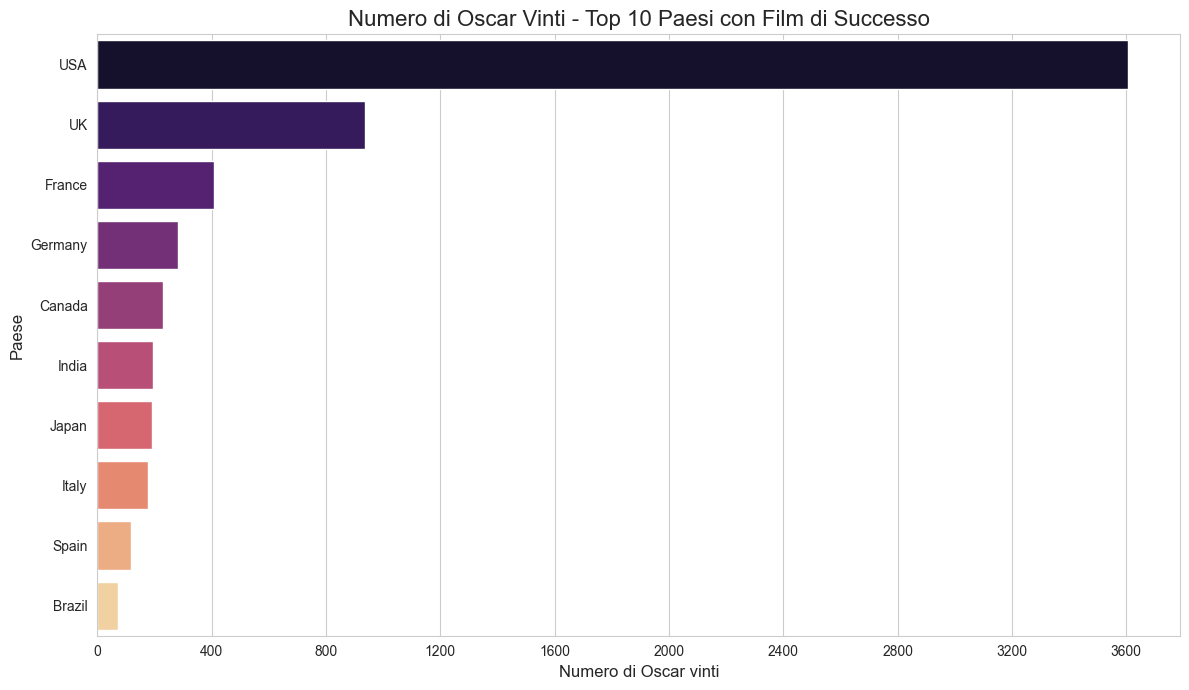

In [19]:
oscars_winners = df_oscars[df_oscars["winner"] == True]
oscars_winners = oscars_winners.merge(df_movies, left_on="film", right_on="name", how="left")
oscars_winners = oscars_winners.merge(df_countries, left_on="id", right_on="id_film", how="left")
oscar_per_country = oscars_winners.groupby("country").size().reset_index(name="oscar_count")

# --- Filtra solo i paesi nel top 10
oscar_top_10 = top_10.merge(oscar_per_country, on="country", how="left").fillna(0)
oscar_top_10 = oscar_top_10.sort_values(by="oscar_count", ascending=False)

# --- Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(
    data=oscar_top_10,
    y='country',
    x='oscar_count',
    palette='magma'
)

plt.title("Numero di Oscar Vinti - Top 10 Paesi con Film di Successo", fontsize=16)
plt.xlabel("Numero di Oscar vinti", fontsize=12)
plt.ylabel("Paese", fontsize=12)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [20]:
fig = px.choropleth(
    oscar_per_country.reset_index(), 
    locations='country', 
    locationmode='country names', 
    color='oscar_count',
    title="Paesi che hanno vinto più Oscar",
    color_continuous_scale='Viridis'
)
fig.show()

Vediamo chiaramente come l'America abbia un controllo sul numero di Oscar vinti, questo probabilmente dovuto alla supremazia di Hollywood come casa produttrice.
La situazione non cambia nelle prime 3 posizioni, mentre successivamente notiamo che i paesi con più film con oscar vinti variano rispetto ai paesi con film di maggior successo, identificando come questo non sia strettamente legato ai film di successo ma più alla quantità di film prodotti, quindi possiamo dedurre che con più film si hanno più possibilità di ottenere una nominazione qualsiasi agli Oscar.


# Hollywood e Cinematografia Francese


In [21]:
hollywood_studios = ["warner", "paramount", "sony", "universal", "warner", "20thcenturyfox"]
pattern = '|'.join(hollywood_studios)

In [22]:
df_hw_studios = df_studios[df_studios["studio"].apply(lambda x: x.lower().replace(" ", "")).str.contains(pattern, na=False, regex=True)].set_index("id_film")

In [23]:
df_movies_filtered = df_released_movies.copy()
df_movies_filtered = df_movies_filtered[(df_movies_filtered['date'] >= 1920) & (df_movies_filtered['date'] <= 2020)]
df_hw_movies = df_movies_filtered[df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)]
df_not_hw_movies = df_movies_filtered[~df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)]

In [24]:
df_hw_movies['year_bin'] = (df_hw_movies['date'] // 5) * 5
df_not_hw_movies['year_bin'] = (df_not_hw_movies['date'] // 5) * 5

df_rating_plot_hw = df_hw_movies.groupby('year_bin')['rating'].mean().reset_index()


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/2335721102.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/2335721102.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [25]:
df_french_movies = pd.merge(left=df_movies_filtered, right=df_countries, left_on='id', right_on='id_film', how="inner")
df_french_movies = df_french_movies[df_french_movies['country'] == 'France']
df_not_french_movies = df_movies_filtered[~df_movies_filtered.index.isin(df_french_movies.index)]

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/3320194749.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



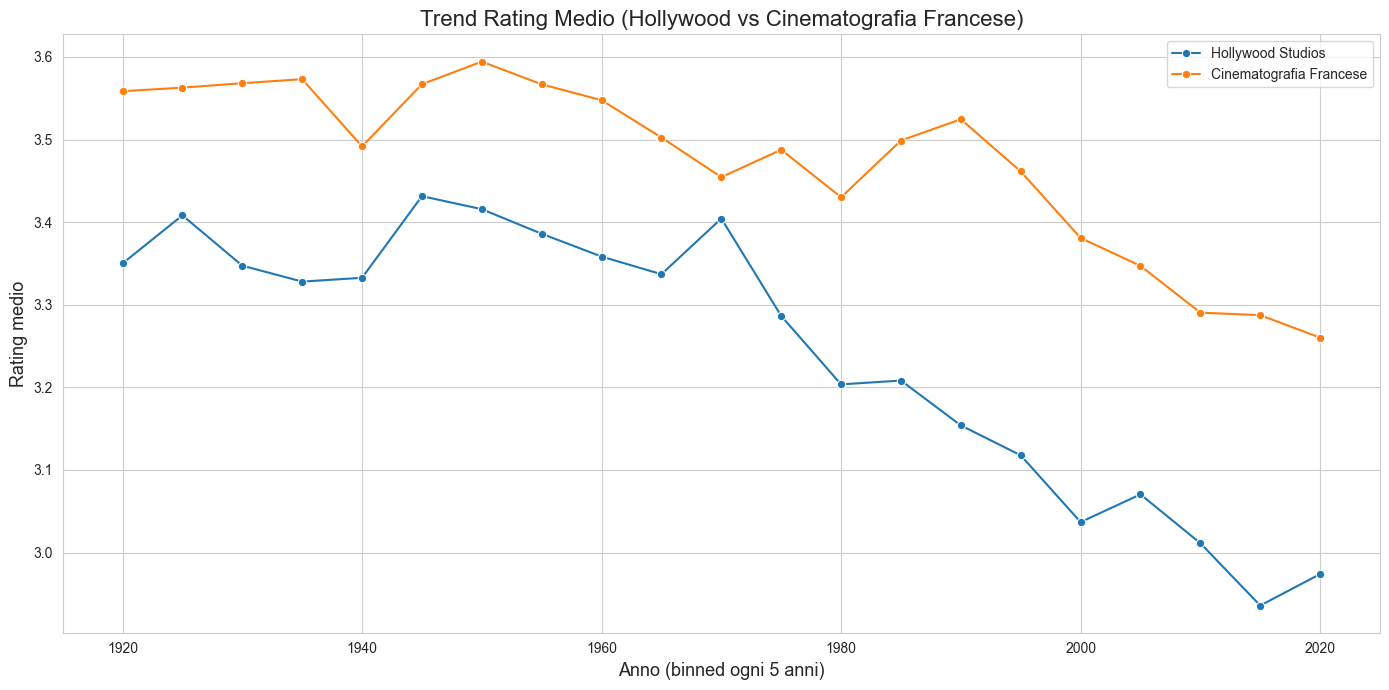

In [26]:
# 2. Crea i "bucket" di 5 anni
df_hw_movies['year_bin'] = (df_hw_movies['date'] // 5) * 5
df_french_movies['year_bin'] = (df_french_movies['date'] // 5) * 5

# 3. Raggruppa per "year_bin" e calcola la media
df_rating_plot_hw = df_hw_movies.groupby('year_bin')['rating'].mean().reset_index()
df_rating_plot_french = df_french_movies.groupby('year_bin')['rating'].mean().reset_index()

# 4. Ora puoi plottare
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_rating_plot_hw, x='year_bin', y='rating', label='Hollywood Studios', marker='o')
sns.lineplot(data=df_rating_plot_french, x='year_bin', y='rating', label='Cinematografia Francese', marker='o')
plt.title("Trend Rating Medio (Hollywood vs Cinematografia Francese)", fontsize=16)
plt.xlabel("Anno (binned ogni 5 anni)", fontsize=13)
plt.ylabel("Rating medio", fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df_other_movies = df_not_french_movies = df_movies_filtered[(~df_movies_filtered.index.isin(df_french_movies.index)) & (~df_movies_filtered.index.isin(df_hw_movies.index))]
# 2. Crea i "bucket" di 5 anni
df_other_movies['year_bin'] = (df_other_movies['date'] // 5) * 5

# 3. Raggruppa per "year_bin" e calcola la media
df_rating_plot_others = df_other_movies.groupby('year_bin')['rating'].mean().reset_index()

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/821365579.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



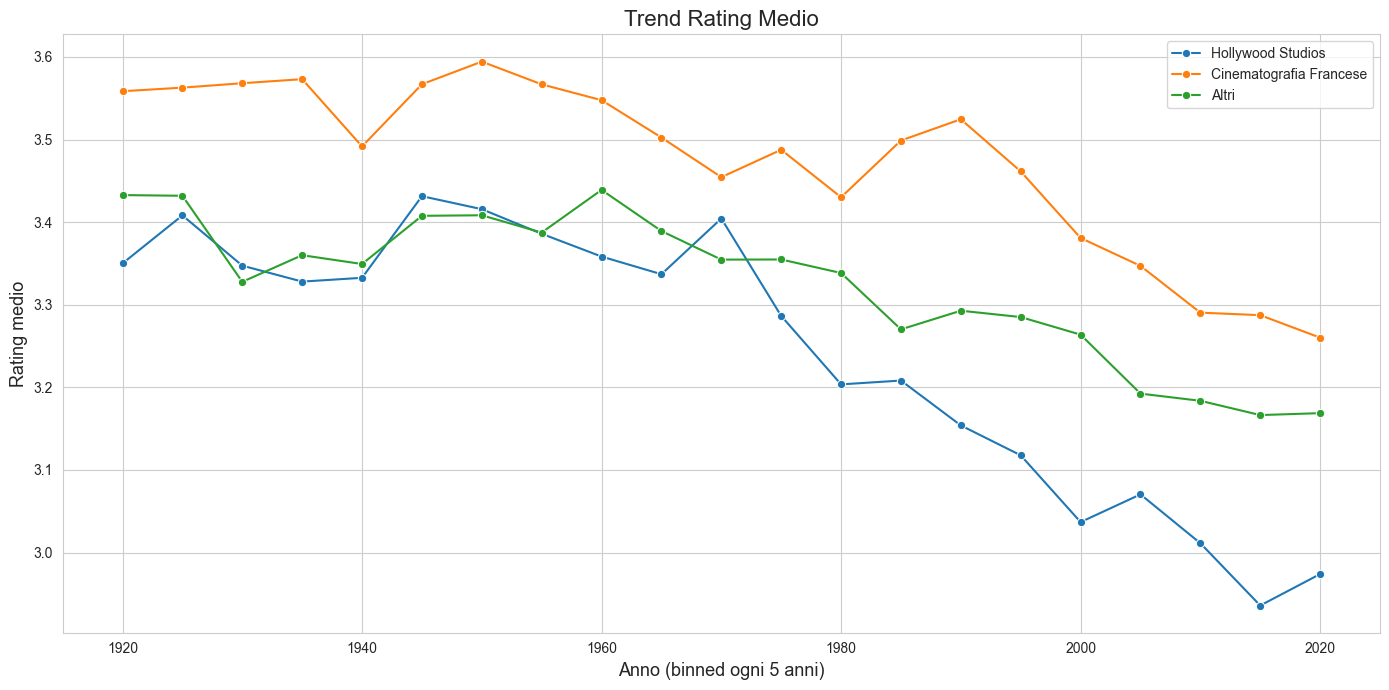

In [28]:
# 4. Ora puoi plottare
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_rating_plot_hw, x='year_bin', y='rating', label='Hollywood Studios', marker='o')
sns.lineplot(data=df_rating_plot_french, x='year_bin', y='rating', label='Cinematografia Francese', marker='o')
sns.lineplot(data=df_rating_plot_others, x='year_bin', y='rating', label='Altri', marker='o')
plt.title("Trend Rating Medio", fontsize=16)
plt.xlabel("Anno (binned ogni 5 anni)", fontsize=13)
plt.ylabel("Rating medio", fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Dopo aver analizzato il rating medio di film dei rinomati Hollywood, della cinematografia francese e aver avuto una visione generale della situazione, poniamo il focus sugli oscar vinti da film francesi e da Hollywood


In [29]:
df_winning = df_oscars[df_oscars['winner'] == True]
df_french_movies = pd.merge(left=df_movies_filtered, right=df_countries, left_on='id', right_on='id_film', how="inner")
df_french_movies = df_french_movies[df_french_movies['country'] == 'France']
df_hw_movies = df_movies_filtered[df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)]

In [30]:
df_winning_hw = pd.merge(left=df_hw_movies, right=df_winning, left_on='name', right_on='film', how='inner')
df_winning_french = pd.merge(left=df_french_movies, right=df_winning, left_on='name', right_on='film', how='inner')
df_winning_hw = df_winning_hw.drop_duplicates(subset=['name_x'])
df_winning_french = df_winning_french.drop_duplicates(subset=['name_x'])

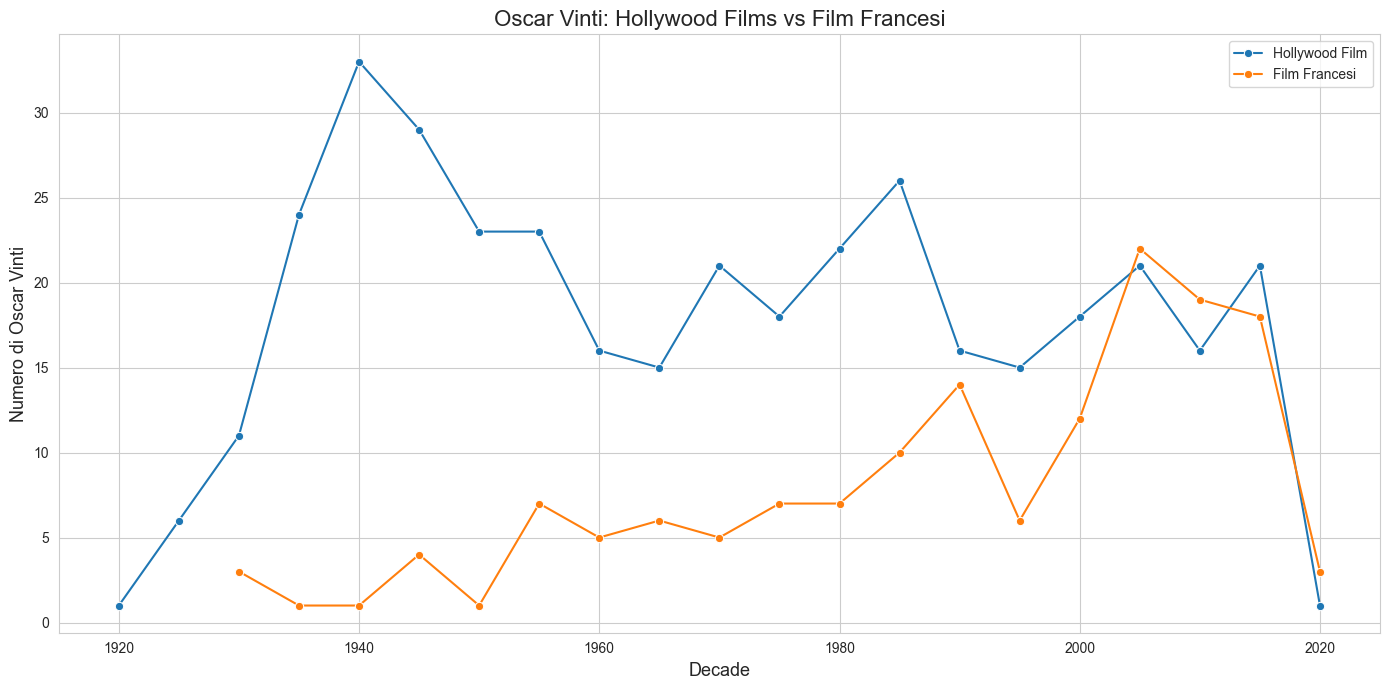

In [31]:
df_winning_hw['decade'] = (df_winning_hw['date'] // 5) * 5
df_winning_french['decade'] = (df_winning_french['date'] // 5) * 5

# 3. Raggruppiamo per decade
hw_decade_counts = df_winning_hw.groupby('decade').size().reset_index(name='count')
french_decade_counts = df_winning_french.groupby('decade').size().reset_index(name='count')

# 4. Plottiamo
plt.figure(figsize=(14, 7))
sns.lineplot(data=hw_decade_counts, x='decade', y='count', marker='o', label='Hollywood Film')
sns.lineplot(data=french_decade_counts, x='decade', y='count', marker='o', label='Film Francesi')

plt.title("Oscar Vinti: Hollywood Films vs Film Francesi", fontsize=16)
plt.xlabel("Decade", fontsize=13)
plt.ylabel("Numero di Oscar Vinti", fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Nonostante il rating medio della critica sulla cinematografia francese sia costantemente negli anni più alto dei film prodotty ad Hollywood, notiamo la supremazia negli anni da parte dei film Hollywoodiani.


Abbiamo osservato che i film prodotti dagli studios di Hollywood hanno generalmente vinto un numero di Oscar nettamente inferiore rispetto a quelli realizzati in Francia. Tuttavia, emerge un'interessante eccezione: nel decennio tra il 2000 e il 2010, i film francesi hanno registrato un'impennata nelle vittorie, avvicinandosi (e in alcuni casi superando) i successi hollywoodiani.

Negli anni successivi, però, Hollywood ha rapidamente ristabilito la sua supremazia, confermando la propria leadership storica nella produzione di film premiati, sostenuta da mezzi produttivi più imponenti, distribuzione globale e una forte influenza culturale sull'industria cinematografica mondiale.


# Il genere è correlato alla vincita di Oscars?


Analiziamo i generi premiati di più nella storia cinematografica


In [41]:
df_oscars['film'] = df_oscars['film'].fillna('')
df_released_movies['name'] = df_released_movies['name'].fillna('')

In [42]:
def normalize_title(title):
    return title.lower().strip()

df_oscars['film_norm'] = df_oscars['film'].apply(normalize_title)
df_released_movies['name_norm'] = df_released_movies['name'].apply(normalize_title)

In [43]:
oscars_winners = df_oscars[df_oscars["winner"] == True]

oscars_winners = oscars_winners.merge(df_released_movies, left_on="film_norm", right_on="name_norm", how="inner")

oscars_genres = oscars_winners.merge(df_genres, left_on="id", right_on="id_film", how="left")

oscars_per_genre = (
    oscars_genres.groupby("genre")
    .size()
    .reset_index(name="oscar_wins")
    .sort_values(by="oscar_wins", ascending=False)
)



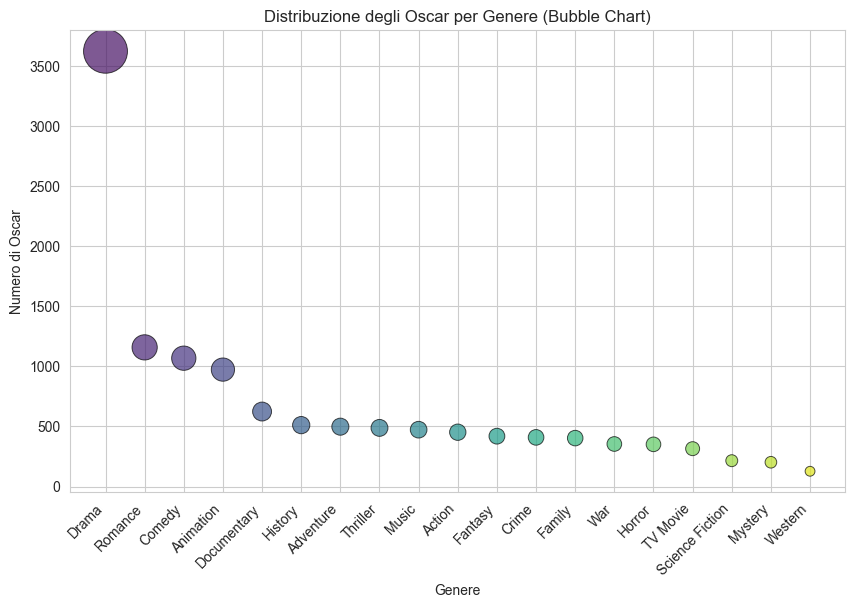

In [44]:
plt.figure(figsize=(10, 6))
scatter=sns.scatterplot(
    x=range(len(oscars_per_genre)), 
    y=oscars_per_genre["oscar_wins"], 
    size=oscars_per_genre["oscar_wins"], 
    sizes=(50, 1000),  # Regola la dimensione delle bolle
    hue=oscars_per_genre["genre"], 
    palette="viridis", 
    edgecolor="black", 
    alpha=0.7,
    legend=False
)
plt.xticks(range(len(oscars_per_genre)), oscars_per_genre["genre"], rotation=45, ha="right")
plt.xlabel("Genere")
plt.ylabel("Numero di Oscar")
plt.title("Distribuzione degli Oscar per Genere (Bubble Chart)")
plt.show()

Non è solo la qualità o la quantità dei film a influenzare il successo agli Oscar.
È anche una questione di scelta strategica dei generi.
In particolare, il Drama è nettamente favorito.


In [47]:
drama_genres = df_genres[df_genres['genre'] == 'Drama']
drama_films = pd.merge(left=drama_genres, right=df_released_movies, left_on='id_film', right_on='id', how='inner')

In [67]:
drama_with_country = pd.merge(drama_films, df_countries, left_on='id', right_on='id_film')

In [74]:
drama_with_top_10 = drama_with_country[drama_with_country['country'].isin(top_10['country'])]
drama_count_top10 = drama_with_top_10['country'].value_counts()

In [ ]:
total_films_per_country = df_countries['country'].value_counts()
total_films_top10 = total_films_per_country.loc[top_10['country']]

country
USA        174489
France      45725
UK          42914
Japan       41362
Germany     41325
Canada      23054
India       22393
Italy       19377
Brazil      17212
Spain       16860
Name: count, dtype: int64

In [76]:
drama_percentage_top10 = (drama_count_top10 / total_films_top10) * 100
drama_percentage_top10

country
Brazil     24.099465
Canada     26.316474
France     30.532531
Germany    33.420448
India      48.381191
Italy      32.115395
Japan      25.209129
Spain      32.935943
UK         26.389989
USA        25.235975
Name: count, dtype: float64

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_22170/3165302411.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




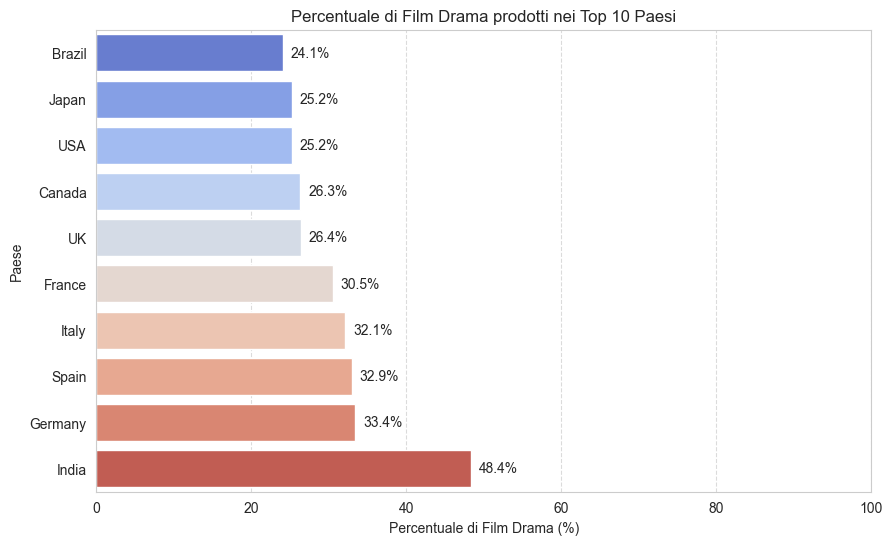

In [80]:
drama_percentage_top10 = drama_percentage_top10.sort_values(ascending=True)  # ascendente per barh

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=drama_percentage_top10, 
    y=drama_percentage_top10.index, 
    palette="coolwarm"
)

for index, value in enumerate(drama_percentage_top10):
    plt.text(value + 1, index, f"{value:.1f}%", va='center')

plt.xlabel('Percentuale di Film Drama (%)')
plt.ylabel('Paese')
plt.title('Percentuale di Film Drama prodotti nei Top 10 Paesi')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Risultato della analisi:

Possiamo affermare che l'America è il paese che ha prodotto film di maggiore successo all'interno nella storia, vincendo anche la maggior parte degli Oscar nei film prodotti nel paese, specificatamente grazie ai film prodotti ad Hollywood.

Abbiamo poi condotto un confronto tra due storici colossi della cinematografia, quella francese e la Hollywoodiana, traendo alcune conclusioni:

- Hollywood storicamente ha sempre vinto più oscars
- La cinematografia francese ha avuto un apprezzamento dalla critica negli anni sempre maggiore ai film prodotti ad Hollywood

La conclusione di questo ramo dell'analisi è finita con la curiosità di scoprire come i generi influenzassero la vittoria di un Oscar. Il drama domina le classifiche di Oscar vinti.


## Come i temi dei film sono cambiati nel tempo

- Alcuni temi sono più presenti in certi paesi rispetto ad altri?
- I film storici sono più frequenti in Europa? I film d’azione dominano negli USA?
- I film di fantascienza sono aumentati in Asia negli ultimi decenni?


Partiremo con una analisi di quali temi sono stati i prevalenti durante i vari anni


In [85]:
df_released_cl_data = df_movies.dropna(subset=["date"])[["id", "date", "rating", "name"]]
df_released_cl_data = df_released_cl_data.dropna(subset=["rating", "date"])
df_released_cl_data["date"] = df_released_cl_data["date"].astype(int)
df_released_cl_data = df_released_cl_data[(1910<df_released_cl_data["date"])&(df_released_cl_data["date"]<2020)]

{'whiskers': [<matplotlib.lines.Line2D at 0x36fb6d760>,
 'caps': [<matplotlib.lines.Line2D at 0x36fb6dfd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x36fb6ff80>],
 'medians': [<matplotlib.lines.Line2D at 0x36fb6f6e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x36fb6c050>],
 'means': []}

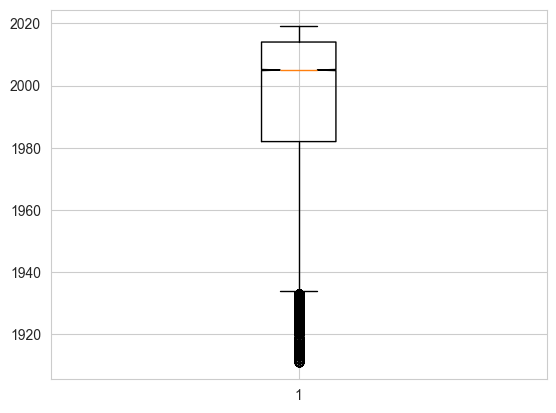

In [86]:
plt.boxplot(df_released_cl_data["date"], df_released_cl_data.groupby("date")["rating"].count().tolist())

In [87]:
data_film_count = df_released_cl_data.groupby("date")["rating"].count()

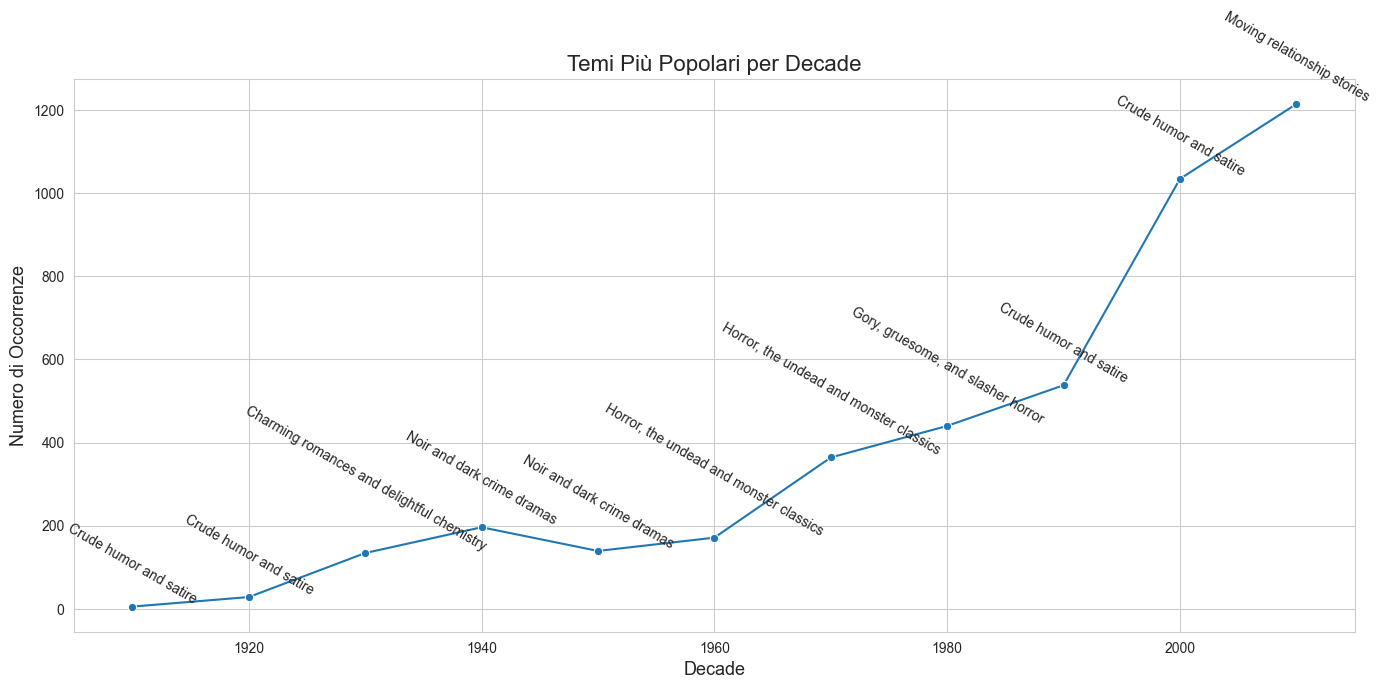

In [116]:
merged_themes = df_themes.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_themes["date_bin"] = (merged_themes["date"] // 10) * 10

# Creazione del dataframe per la conta dei temi per decada
df_date_theme = merged_themes[["date_bin", "theme"]].groupby("date_bin").value_counts().to_frame()

# Prendere il tema più popolare per ogni decade
idx = df_date_theme.groupby(level=0)["count"].idxmax()
df_date_hot_theme = df_date_theme.loc[idx].reset_index()

# Configurazione della figura per una visualizzazione chiara
plt.figure(figsize=(14, 7))

# Utilizzare lineplot di Seaborn per tracciare i dati
sns.lineplot(data=df_date_hot_theme, x='date_bin', y='count', marker='o')

# Aggiungere etichette ai punti
for i, txt in enumerate(df_date_hot_theme["theme"]):
    plt.text(df_date_hot_theme["date_bin"].iloc[i], df_date_hot_theme["count"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

# Aggiungere titolo e etichette agli assi
plt.title("Temi Più Popolari per Decade", fontsize=16)
plt.xlabel("Decade", fontsize=13)
plt.ylabel("Numero di Occorrenze", fontsize=13)

# Aggiungere la griglia
plt.grid(True)

# Ottimizzare il layout
plt.tight_layout()

# Visualizzare il grafico
plt.show()

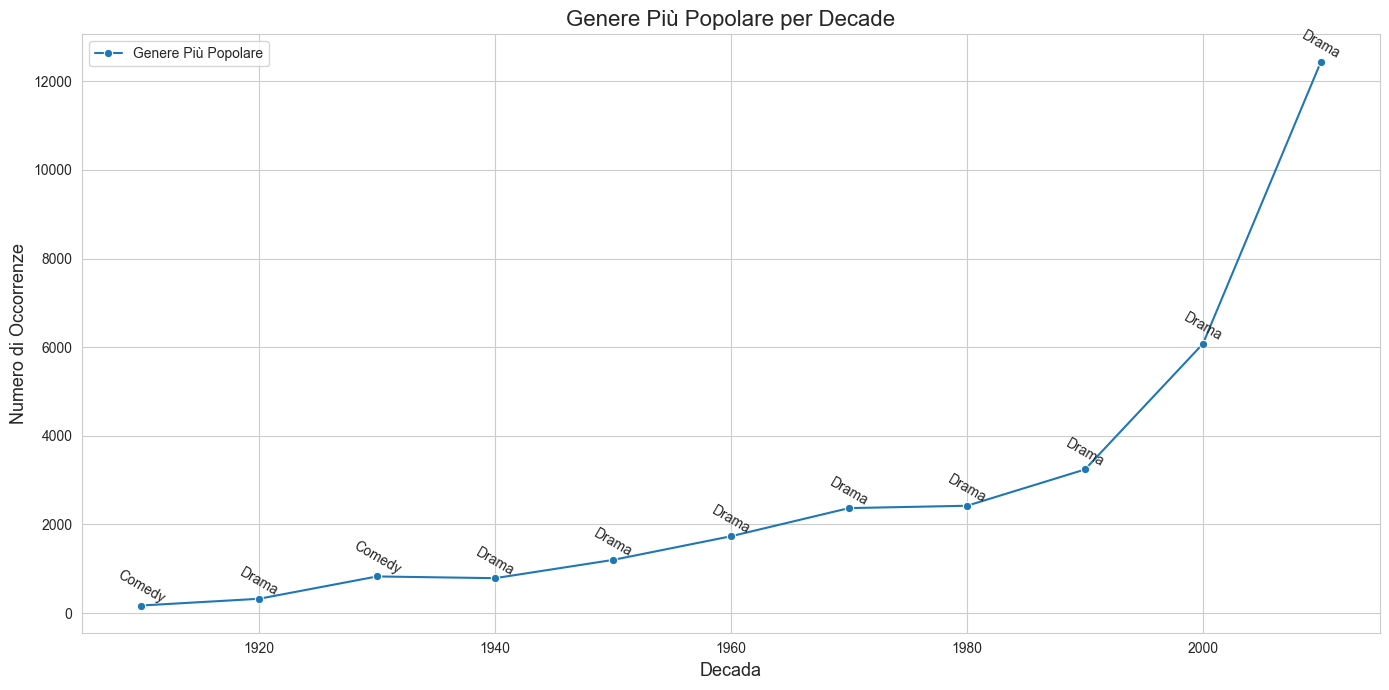

In [103]:
# Creazione della colonna 'date_bin' con decadi
merged_genre = df_genres.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_genre["date_bin"] = (merged_genre["date"] // 10) * 10

# Creazione del dataframe per la conta dei generi per decada
df_date_genre = merged_genre[["date_bin", "genre"]].groupby("date_bin").value_counts().to_frame()

# Prendere il genere più popolare per ogni decade
idx = df_date_genre.groupby(level=0)["count"].idxmax()
df_date_hot_genre = df_date_genre.loc[idx].reset_index()

# Configurazione della figura per una visualizzazione chiara
plt.figure(figsize=(14, 7))

# Utilizzare lineplot di Seaborn per tracciare i dati
sns.lineplot(data=df_date_hot_genre, x='date_bin', y='count', marker='o', label='Genere Più Popolare')

# Aggiungere etichette ai punti
for i, txt in enumerate(df_date_hot_genre["genre"]):
    plt.text(df_date_hot_genre["date_bin"].iloc[i], df_date_hot_genre["count"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

# Aggiungere titolo e etichette agli assi
plt.title("Genere Più Popolare per Decade", fontsize=16)
plt.xlabel("Decada", fontsize=13)
plt.ylabel("Numero di Occorrenze", fontsize=13)

# Aggiungere la griglia
plt.grid(True)

# Ottimizzare il layout
plt.tight_layout()

# Visualizzare il grafico
plt.show()

In [105]:
genre_rating = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).agg(['mean', 'count'])["rating"].reset_index()
rating_per_year = merged_genre[["date_bin", "rating"]].groupby(["date_bin"]).count().reset_index().set_index("date_bin")

In [106]:
rating_per_year_dict = rating_per_year.to_dict()
rating_per_year_dict

{'rating': {1910: 596,
  1920: 1243,
  1930: 3938,
  1940: 4576,
  1950: 5633,
  1960: 7804,
  1970: 10878,
  1980: 13738,
  1990: 16802,
  2000: 29552,
  2010: 56717}}

In [107]:
genre_rating["mean_count"] = genre_rating["mean"] * genre_rating["count"]

In [108]:
genre_rating["w_avg"] = genre_rating.apply(lambda x: x["mean_count"]/rating_per_year["rating"][x["date_bin"]], axis=1)

In [109]:
df_highest_genre = genre_rating.loc[genre_rating.groupby("date_bin")["w_avg"].idxmax()].reset_index(drop=True)

In [110]:
genre_rating_dropped = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).mean().dropna(subset=["rating"])

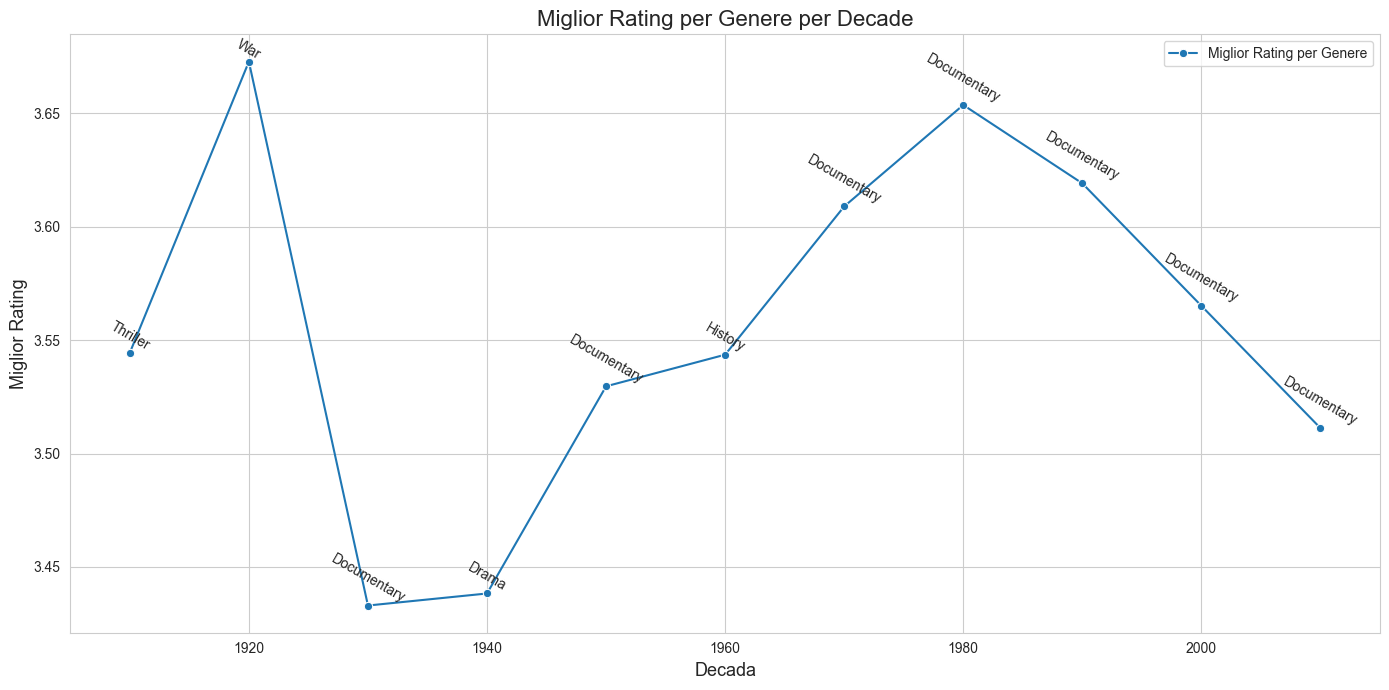

In [111]:
idx = genre_rating_dropped.groupby(level=0)["rating"].idxmax()
df_date_best_genre = genre_rating_dropped.loc[idx].reset_index()

# Configurazione della figura per una visualizzazione chiara
plt.figure(figsize=(14, 7))

# Utilizzare lineplot di Seaborn per tracciare i dati
sns.lineplot(data=df_date_best_genre, x='date_bin', y='rating', marker='o', label='Miglior Rating per Genere')

# Aggiungere etichette ai punti
for i, txt in enumerate(df_date_best_genre["genre"]):
    plt.text(df_date_best_genre["date_bin"].iloc[i], df_date_best_genre["rating"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

# Aggiungere titolo e etichette agli assi
plt.title("Miglior Rating per Genere per Decade", fontsize=16)
plt.xlabel("Decada", fontsize=13)
plt.ylabel("Miglior Rating", fontsize=13)

# Aggiungere la griglia
plt.grid(True)

# Ottimizzare il layout
plt.tight_layout()

# Visualizzare il grafico
plt.show()

Avendo ora una idea del comportamento dei temi durante gli anni, possiamo ora analizzarne i comportamenti geograficamente.


In [ ]:
# Filtrare i temi romantici

romantic_themes = [
"Moving relationship stories",
"Heartbreaking and moving family drama",
"Touching and sentimental family stories"
]

# Filtrare i dati per i temi romantici

romantic_data = themes_geo[themes_geo["theme"].isin(romantic_themes)]
"""

# Calcolare la percentuale di film romantici per paese

romantic_counts = romantic_data.groupby("Country").size().reset_index(name="Romantic_Count")
total_movies_per_country = theme_counts.groupby("Country")["Total_Movies"].first().reset_index()
romantic_percentage = romantic_counts.merge(total_movies_per_country, on="Country")
romantic_percentage["Percentage"] = (romantic_percentage["Romantic_Count"] / romantic_percentage["Total_Movies"]) \* 100

# Ordinare i paesi per percentuale di film romantici

romantic_percentage = romantic_percentage.sort_values(by="Percentage", ascending=False)

# Visualizzare i primi 10 paesi

plt.figure(figsize=(12, 6))
sns.barplot(data=romantic_percentage.head(10), x="Percentage", y="Country", palette="Reds_r")
plt.title("Top 10 Paesi con la Percentuale più Alta di Film Romantici", fontsize=16)
plt.xlabel("Percentuale di Film Romantici (%)", fontsize=12)
plt.ylabel("Paese", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()"""
romantic_data


,Country,Theme
2,UK,Moving relationship stories
10,USA,Moving relationship stories
18,UK,Moving relationship stories
26,USA,Moving relationship stories
34,UK,Moving relationship stories
...,...,...
2699833,Malta,Moving relationship stories
2699834,Malta,Touching and sentimental family stories
2699836,NaN,Moving relationship stories
2699850,China,Moving relationship stories


In [112]:
releases = df_releases.merge(df_countries, left_on="id_film", right_on="id_film", how="left")

In [113]:
themes_geo = releases.merge(df_themes, on="id_film", how="inner")[["country_y", "theme"]]
themes_geo.columns = ["Country", "Theme"]

In [118]:
theme_counts = themes_geo.groupby(["Country", "Theme"]).size().reset_index(name="Count")
total_movies_per_country = theme_counts.groupby("Country")["Count"].sum().reset_index()
total_movies_per_country.columns = ["Country", "Total_Movies"]
theme_counts = theme_counts.merge(total_movies_per_country, on="Country")

theme_counts["Percentage"] = (theme_counts["Count"] / theme_counts["Total_Movies"]) * 100
theme_counts

,Country,Theme,Count,Total_Movies,Percentage
0,Afghanistan,Disastrous voyages and heroic survival,3,65,4.615385
1,Afghanistan,Emotional and touching family dramas,7,65,10.769231
2,Afghanistan,Epic adventure and breathtaking battles,3,65,4.615385
3,Afghanistan,Heartbreaking and moving family drama,7,65,10.769231
4,Afghanistan,Historical battles and epic heroism,1,65,1.538462
...,...,...,...,...,...
5898,Zambia,Thought-provoking sci-fi action and future tec...,1,2,50.000000
5899,Zimbabwe,"Gripping, intense violent crime",30,120,25.000000
5900,Zimbabwe,Heartbreaking and moving family drama,30,120,25.000000
5901,Zimbabwe,Politics and human rights,30,120,25.000000


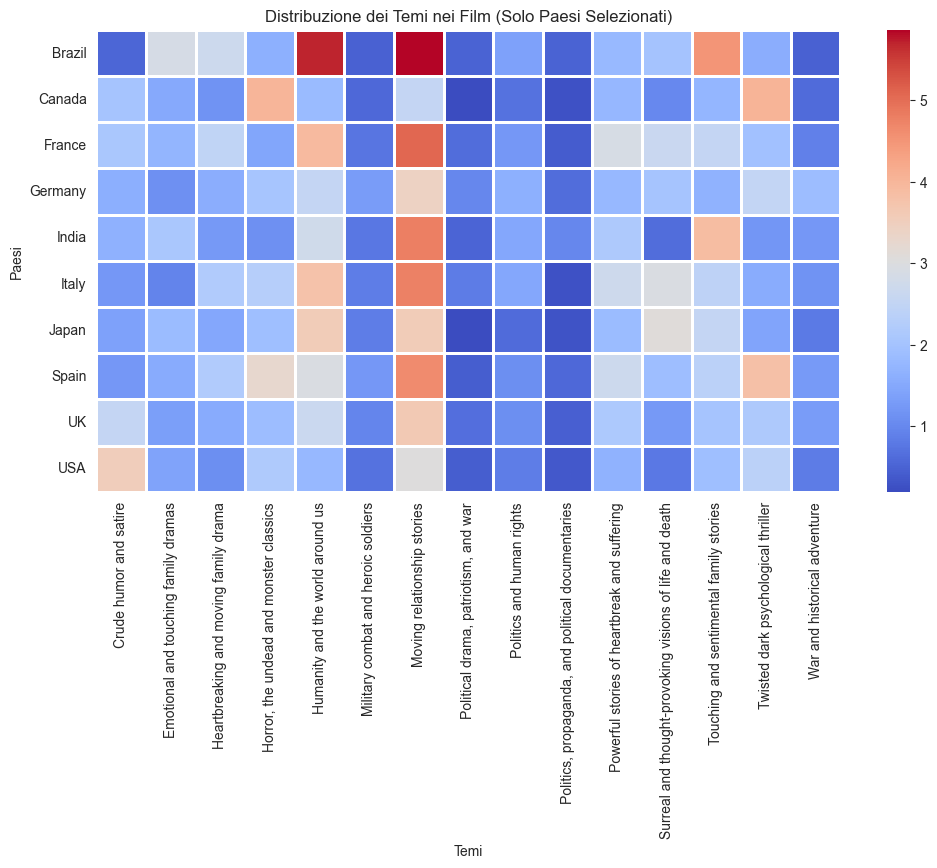

In [120]:
#aggiungere eventuali paesi di interesse
# paesi_interessati = ["USA", "Italy", "Germany", "France", "China", "Japan", "India", "UK"]
paesi_interessati = top_10['country']
To_filter=theme_counts["Theme"].value_counts().nlargest(15).index
filtered_df_themes = theme_counts[theme_counts["Theme"].isin(To_filter)]

pivot_table_filtered = filtered_df_themes[filtered_df_themes["Country"].isin(paesi_interessati)] \
    .pivot(index="Country", columns="Theme", values="Percentage")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table_filtered, cmap="coolwarm", linewidths=1, fmt=".1f")
plt.title("Distribuzione dei Temi nei Film (Solo Paesi Selezionati)")
plt.xlabel("Temi")
plt.ylabel("Paesi")
plt.show()

Abbiamo scelto di prendere solo certi paesi in considerazione, per non saturare la tabella, ma avere comunque una buona idea generale dei temi e della loro dispersione.
Possiamo cosi nottare che ci sono temi più prevalenti nei paesi, ma molti di questi si bilanciano in quantità, non evidenziandone la loro importanza, rispetto ad altri che cadono subito all'occhio.
Possiamo notare chiaramente che il genere "Moving relationship stories" è presente in tutti i paesi, durante lo sviluppo negli anni.


######

vietati in quale stato (raggruppare i rating di PG vietato ai minori)

quante uscite per ogni anno(anche in base a quanti "caratteristica varia: ")

film vietati ai minori

istogramma di frequenze

notare che i rating della critica sono diversi da quelli degli utenti (quindi magari aggiungere qualcosa anche sopra )

dare uno scopo alla propria analisi (molto intelligente fare 2 analisi diverse)
dove si dà un senso alla analisi che si fà tipo " Notare che l'africa ha un sacco di oscar"
